In [1]:
import numpy as np
import pandas as pd

# Timestamp Object
Time stamp reference particular moments in time (e.g., May 8th, 2026 at 9:00am)

## Creating Timestamp objects

In [10]:
# creating a timestamp
type(pd.Timestamp('2026/05/08'))

pandas._libs.tslibs.timestamps.Timestamp

In [9]:
# variations
pd.Timestamp('2026-05-08')
pd.Timestamp('2026, 05, 08')

Timestamp('2026-05-08 00:00:00')

In [6]:
# only year
pd.Timestamp('2026')

Timestamp('2026-01-01 00:00:00')

In [8]:
# using text
pd.Timestamp('8th May 2026')

Timestamp('2026-05-08 00:00:00')

In [12]:
# providing time also
pd.Timestamp('5th May 2026 9:40am')

Timestamp('2026-05-05 09:40:00')

In [ ]:
# AM and PM

In [18]:
# using datetime.datetime object
import datetime as dt

x = pd.Timestamp(dt.datetime(2026,1,4,9,21,45))
x

Timestamp('2026-01-04 09:21:45')

In [21]:
# fetching attributes
x.year
x.month
x.day
x.hour
x.minute
x.second

45

In [20]:
# why seperate objects to handle data and time when python already has datetime functionality?

* syntax wise datetime is very convenient<br>
* But the performance takes a hit while working with huge data. List vs Numpy Array<br>
* The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy.<br>
* The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [22]:
import numpy as np
date = np.array('2026-05-08', dtype=np.datetime64)
date

array('2026-05-08', dtype='datetime64[D]')

In [23]:
date + np.arange(12)

array(['2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11',
       '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15',
       '2026-05-16', '2026-05-17', '2026-05-18', '2026-05-19'],
      dtype='datetime64[D]')

* Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large

* Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

* From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

# DatetimeIndex Object
A collection of pandas timestamp

In [25]:
# from strings
pd.DatetimeIndex(['2026/1/1','2025/1/1','2024/1/1'])[0]

Timestamp('2026-01-01 00:00:00')

In [26]:
# using python datetime object
pd.DatetimeIndex([dt.datetime(2026,1,1),dt.datetime(2025,1,1),dt.date(2024,1,1)])

DatetimeIndex(['2026-01-01', '2025-01-01', '2024-01-01'], dtype='datetime64[ns]', freq=None)

In [30]:
# using pd.timestamps
dt_index = pd.DatetimeIndex([pd.Timestamp(2026,1,1),pd.Timestamp(2025,1,1),pd.Timestamp(2024,1,1)])

In [31]:
# using datetimeindex as series index
pd.Series([1,2,3],index=dt_index)

2026-01-01    1
2025-01-01    2
2024-01-01    3
dtype: int64

# date_range function

In [37]:
# generate daily dates in a given range
pd.date_range(start='2026/5/8',end='2026/6/30', freq='2D')

DatetimeIndex(['2026-05-08', '2026-05-10', '2026-05-12', '2026-05-14',
               '2026-05-16', '2026-05-18', '2026-05-20', '2026-05-22',
               '2026-05-24', '2026-05-26', '2026-05-28', '2026-05-30',
               '2026-06-01', '2026-06-03', '2026-06-05', '2026-06-07',
               '2026-06-09', '2026-06-11', '2026-06-13', '2026-06-15',
               '2026-06-17', '2026-06-19', '2026-06-21', '2026-06-23',
               '2026-06-25', '2026-06-27', '2026-06-29'],
              dtype='datetime64[ns]', freq='2D')

In [ ]:
# alternate days in a given range
pd.date_range(start='2026/5/8',end='2026/6/30', freq='2D')

In [38]:
# B -> business days
pd.date_range(start='2026/5/8',end='2026/6/30', freq='B')

DatetimeIndex(['2026-05-08', '2026-05-11', '2026-05-12', '2026-05-13',
               '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19',
               '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-25',
               '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29',
               '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04',
               '2026-06-05', '2026-06-08', '2026-06-09', '2026-06-10',
               '2026-06-11', '2026-06-12', '2026-06-15', '2026-06-16',
               '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-22',
               '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26',
               '2026-06-29', '2026-06-30'],
              dtype='datetime64[ns]', freq='B')

In [40]:
# w -> one weekk per days
pd.date_range(start='2026/5/8',end='2026/6/30', freq='W-SAT')

DatetimeIndex(['2026-05-09', '2026-05-16', '2026-05-23', '2026-05-30',
               '2026-06-06', '2026-06-13', '2026-06-20', '2026-06-27'],
              dtype='datetime64[ns]', freq='W-SAT')

In [43]:
# H -> Hourly date(factor)
pd.date_range(start='2026/5/8',end='2026/6/30',freq='6H')

C:\Users\Ranjan Singh\AppData\Local\Temp\ipykernel_21200\3308600459.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2026/5/8',end='2026/6/30',freq='6H')


DatetimeIndex(['2026-05-08 00:00:00', '2026-05-08 06:00:00',
               '2026-05-08 12:00:00', '2026-05-08 18:00:00',
               '2026-05-09 00:00:00', '2026-05-09 06:00:00',
               '2026-05-09 12:00:00', '2026-05-09 18:00:00',
               '2026-05-10 00:00:00', '2026-05-10 06:00:00',
               ...
               '2026-06-27 18:00:00', '2026-06-28 00:00:00',
               '2026-06-28 06:00:00', '2026-06-28 12:00:00',
               '2026-06-28 18:00:00', '2026-06-29 00:00:00',
               '2026-06-29 06:00:00', '2026-06-29 12:00:00',
               '2026-06-29 18:00:00', '2026-06-30 00:00:00'],
              dtype='datetime64[ns]', length=213, freq='6h')

In [44]:
# M -> Month end
pd.date_range(start='2026/5/8',end='2026/6/30', freq='M')

C:\Users\Ranjan Singh\AppData\Local\Temp\ipykernel_21200\968797071.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(start='2026/5/8',end='2026/6/30', freq='M')


DatetimeIndex(['2026-05-31', '2026-06-30'], dtype='datetime64[ns]', freq='ME')

In [45]:
# MS -> Month start
pd.date_range(start='2026/5/8',end='2026/6/30', freq='MS')

DatetimeIndex(['2026-06-01'], dtype='datetime64[ns]', freq='MS')

In [46]:
# A -> Year end
pd.date_range(start='2026/5/8',end='2032/6/30', freq='A')

C:\Users\Ranjan Singh\AppData\Local\Temp\ipykernel_21200\1862772484.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  pd.date_range(start='2026/5/8',end='2032/6/30', freq='A')


DatetimeIndex(['2026-12-31', '2027-12-31', '2028-12-31', '2029-12-31',
               '2030-12-31', '2031-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

In [48]:
# using periods(number of results)
pd.date_range(start='2026/5/8',periods=25, freq='H')

C:\Users\Ranjan Singh\AppData\Local\Temp\ipykernel_21200\108692278.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pd.date_range(start='2026/5/8',periods=25, freq='H')


DatetimeIndex(['2026-05-08 00:00:00', '2026-05-08 01:00:00',
               '2026-05-08 02:00:00', '2026-05-08 03:00:00',
               '2026-05-08 04:00:00', '2026-05-08 05:00:00',
               '2026-05-08 06:00:00', '2026-05-08 07:00:00',
               '2026-05-08 08:00:00', '2026-05-08 09:00:00',
               '2026-05-08 10:00:00', '2026-05-08 11:00:00',
               '2026-05-08 12:00:00', '2026-05-08 13:00:00',
               '2026-05-08 14:00:00', '2026-05-08 15:00:00',
               '2026-05-08 16:00:00', '2026-05-08 17:00:00',
               '2026-05-08 18:00:00', '2026-05-08 19:00:00',
               '2026-05-08 20:00:00', '2026-05-08 21:00:00',
               '2026-05-08 22:00:00', '2026-05-08 23:00:00',
               '2026-05-09 00:00:00'],
              dtype='datetime64[ns]', freq='h')

# to_datetime functions
converts an existing objects to pandas timestamp/datetimeindex object

In [57]:
# simple series example
s = pd.Series(['2026/1/1','2025/1/1','2024/1/1'])
pd.to_datetime(s).dt.day_name()

0     Thursday
1    Wednesday
2       Monday
dtype: object

In [70]:
# with errors
s = pd.Series(['2026/1/1','2025/1/1','2024/130/1'])
s.to_datetime(s,errors='coerce').dt.year

AttributeError: 'Series' object has no attribute 'to_datetime'

In [72]:
df = pd.read_csv('C:/Users/Ranjan Singh/Downloads/all_pandas_data_sets/datasets-6/expense_data.csv')
df.shape

(277, 11)

In [78]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [77]:
df['Date'] = pd.to_datetime(df['Date'])

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


# dt accessor
Accessor object for datetimelike properties of the Series values

In [81]:
df['Date'].dt.month_name()

0         March
1         March
2         March
3         March
4         March
         ...   
272    November
273    November
274    November
275    November
276    November
Name: Date, Length: 277, dtype: object

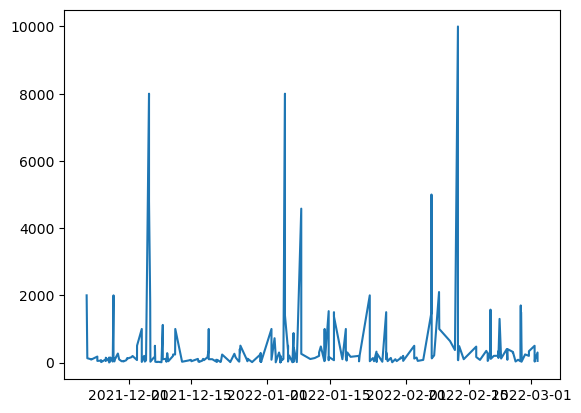

In [82]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

In [84]:
# days name wise bar chart/month wise bar chart
df['day_name'] = df['Date'].dt.day_name()

In [85]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday


<Axes: xlabel='day_name'>

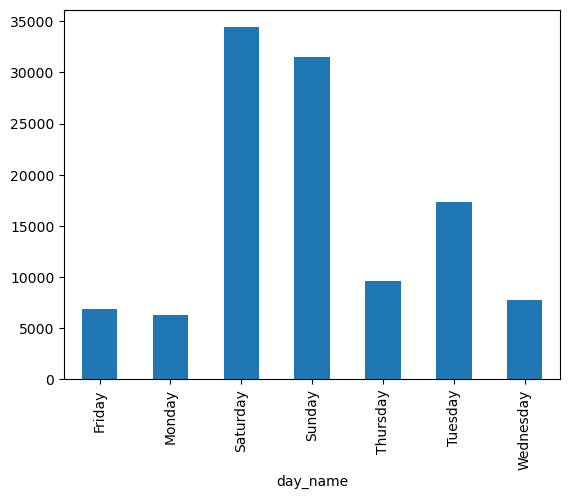

In [87]:
df.groupby('day_name')['INR'].sum().plot(kind='bar')

In [88]:
df['month_name'] = df['Date'].dt.month_name()

In [89]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,Wednesday,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,Wednesday,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,Tuesday,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,Tuesday,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,Tuesday,March


<Axes: xlabel='month_name'>

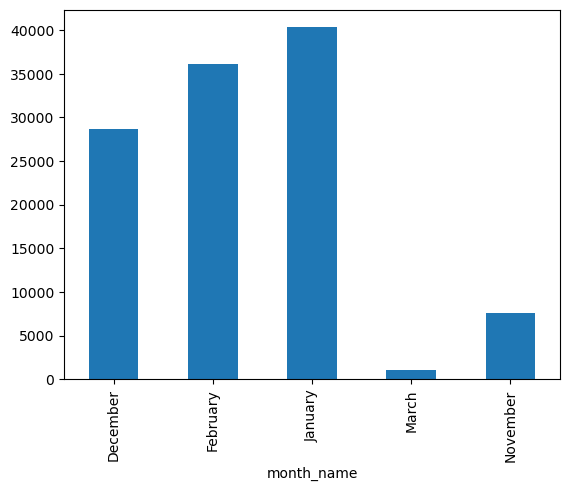

In [90]:
df.groupby('month_name')['INR'].sum().plot(kind='bar')

In [91]:
df[df['Date'].dt.is_month_end]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,day_name,month_name
7,2022-02-28 11:56:00,CUB - online payment,Food,NaN,Pizza,339.15,Expense,NaN,339.15,INR,339.15,Monday,February
8,2022-02-28 11:45:00,CUB - online payment,Other,NaN,From kumara,200.00,Income,NaN,200.00,INR,200.00,Monday,February
61,2022-01-31 08:44:00,CUB - online payment,Transportation,NaN,Vnr to apk,50.00,Expense,NaN,50.00,INR,50.00,Monday,January
62,2022-01-31 08:27:00,CUB - online payment,Other,NaN,To vicky,200.00,Expense,NaN,200.00,INR,200.00,Monday,January
63,2022-01-31 08:26:00,CUB - online payment,Transportation,NaN,To ksr station,153.00,Expense,NaN,153.00,INR,153.00,Monday,January
242,2021-11-30 14:24:00,CUB - online payment,Gift,NaN,Bharath birthday,115.00,Expense,NaN,115.00,INR,115.00,Tuesday,November
243,2021-11-30 14:17:00,CUB - online payment,Food,NaN,Lunch with company,128.00,Expense,NaN,128.00,INR,128.00,Tuesday,November
244,2021-11-30 10:11:00,CUB - online payment,Food,NaN,Breakfast,70.00,Expense,NaN,70.00,INR,70.00,Tuesday,November


# Well Done !